# Project SQL: Data Discovery with the Chinook Database

Welcome to your first major hands-on data exploration project. In this assignment, you will be stepping into the role of a data analyst querying the Chinook database: a sample dataset representing a digital media store, complete with information about artists, albums, tracks, customers, and business sales.

The core objective of this project is to transition you from simply writing code to thinking like a data scientist. To do that, our journey follows a deliberate, four-fold progression:



### Phase 1. Master the Mechanics (Get Familiar with SQL)



Before you can extract deep insights, you need to speak the language. You will start by practicing the fundamental mechanics of SQL using the SQL statements below: learning how to filter data, join tables, group metrics, and aggregate numbers. Think of this as learning how to move around the data environment smoothly.  As a starting point, pick a single table and answer the "How many ...?" questions using SQL.  Then repeat the process for each table.



### Phase 2. Map the Terrain (Get Familiar with the Data)



Data never exists in a vacuum. By writing queries, you will uncover the shape, structure, and quirks of the Chinook dataset. Again, using the SQL statements below, you'll learn how the tables relate to one another, what a single row represents in different contexts, and where specific types of information live.  Here's where you should get familiar with the ERD and join tables in various ways.



### Phase 3. Answer Guided Questions



Once you know the syntax and understand the data structure, you will put your skills to work solving specific business problems. Below are sets of explicit questions to answer using SQL. This phase mimics standard reporting: you are handed a specific prompt, and your job is to translate that prompt into an accurate, data-driven answer.

Here are some practice questions:
- https://github.com/LucasMcL/15-sql_queries_02-chinook/blob/master/README.md
- [Using the R language]( https://rpubs.com/enext777/636199 )
- [Search Google]( https://www.google.com/search?q=chinook+database+questions )
- Ask AI to generate some questions for you.  Be sure to mention the Chinook data set.




### Phase 4. Ask and Answer Your Own Questions


This final phase is the most critical part of the project. The true hallmark of a great data scientist isn't just answering the questions you're handed; it's having the curiosity and intuition to formulate your own questions.

You are tasked with looking at the Chinook dataset, generating your own original hypotheses or business questions, and writing the SQL required to answer them.

Demonstrate that you know SQL fundamentals by posting a question for each SQL statement below and then using the SQL statement to answer you question.

You will use the material from this phase for the presentation.



## Why This Matters: The Path to Your Capstone


Learning to ask your own questions is the exact skill you will rely on for your final capstone project. In your capstone, you will choose a dataset from your own field of interest. No one will hand you a list of prompts or a guide telling you what to look for.

Use this project as your sandbox. Mastering the ability to interrogate a database now will give you the framework you need to discover meaningful, independent insights in your capstone later.



## Chinook data set

See the lecture on SQLite3 using the Chinook data set to set up the software, database, and tables, as well as for the links to ancillary information about the data set.


In [86]:
# Install the sqlite package for Ubuntu
# Download the Chinook sqlite database

In [87]:
import sqlite3 as db
import pandas as pd

In [88]:
%%capture
%%bash
apt-get update
apt-get install -y sqlite3

In [89]:
!sqlite3 --version

3.37.2 2022-01-06 13:25:41 872ba256cbf61d9290b571c0e6d82a20c224ca3ad82971edc46b29818d5dalt1


In [90]:
%%bash
[ -f chinook.zip ] ||
  curl -s -O https://www.sqlitetutorial.net/wp-content/uploads/2018/03/chinook.zip
unzip -l chinook.zip


Archive:  chinook.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   884736  2015-11-29 10:53   chinook.db
---------                     -------
   884736                     1 file


In [91]:
!rm -f chinook.db

In [92]:
!unzip -u chinook.zip

Archive:  chinook.zip
  inflating: chinook.db              


In [93]:
!ls -la

total 1180
drwxr-xr-x 1 root root   4096 Jul  8 04:56 .
drwxr-xr-x 1 root root   4096 Jul  8 03:36 ..
-rw-r--r-- 1 root root 884736 Nov 29  2015 chinook.db
-rw-r--r-- 1 root root 305596 Jul  8 03:40 chinook.zip
drwxr-xr-x 4 root root   4096 Jun  4 13:32 .config
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data


## Use SQL queries to pull specific information

Do NOT pull all the data and then filter using DataFrame methods.  The initial purpose is to get familiar with SQL.




### Basic Queries


- Uncovering the "Shape": Counting the Total Rows Across Main Tables

In [94]:
# Checking the size/shape of the primary tables

query_shape = '''
SELECT 'Customers' AS TableName, COUNT(*) AS TotalRows FROM customers
UNION ALL
SELECT 'Invoices', COUNT(*) FROM invoices
UNION ALL
SELECT 'Invoice Items', COUNT(*) FROM invoice_items
UNION ALL
SELECT 'Tracks', COUNT(*) FROM tracks
UNION ALL
SELECT 'Employees', COUNT(*) FROM employees;
'''

print("Mapping the dataset's shape (Row counts)...")
df_shape = pd.read_sql_query(query_shape, db_con)
df_shape

Mapping the dataset's shape (Row counts)...


,TableName,TotalRows
0,Customers,59
1,Invoices,412
2,Invoice Items,2240
3,Tracks,3503
4,Employees,8


- Understanding the "Structure" i.e., How Tracks are Distributed Across Genres

In [95]:
# Analyze the store's catalog structure by counting tracks per genre

query = '''
SELECT
    g.Name AS GenreName,
    COUNT(t.TrackId) AS TotalTracks,
    ROUND(COUNT(t.TrackId) * 100.0 / (SELECT COUNT(*) FROM tracks), 2) AS PercentageOfCatalog
FROM tracks t
INNER JOIN genres g ON t.GenreId = g.GenreId
GROUP BY g.Name
ORDER BY TotalTracks DESC;
'''

#print("Analyzing database structure (Genre distribution)...")
df_structure = pd.read_sql_query(query, db_con)
df_structure

,GenreName,TotalTracks,PercentageOfCatalog
0,Rock,1297,37.03
1,Latin,579,16.53
2,Metal,374,10.68
3,Alternative & Punk,332,9.48
4,Jazz,130,3.71
5,TV Shows,93,2.65
6,Blues,81,2.31
7,Classical,74,2.11
8,Drama,64,1.83
9,R&B/Soul,61,1.74


- Spotting "Quirks" i.e., Finding Missing Composers (Data Completeness Audit)

In [96]:
# Identify missing or incomplete data fields (Quirks)

query = '''
SELECT
    g.Name AS GenreName,
    COUNT(*) AS TotalTracks,
    SUM(CASE WHEN t.Composer IS NULL THEN 1 ELSE 0 END) AS MissingComposers,
    ROUND(SUM(CASE WHEN t.Composer IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS PercentMissing
FROM tracks t
INNER JOIN genres g ON t.GenreId = g.GenreId
GROUP BY g.Name
ORDER BY PercentMissing DESC
LIMIT 10;
'''
#print("Auditing data quirks (Where is Composer data missing?)...")
df_quirks_nulls = pd.read_sql_query(query, db_con)
df_quirks_nulls

,GenreName,TotalTracks,MissingComposers,PercentMissing
0,TV Shows,93,93,100.00
1,Science Fiction,13,13,100.00
2,Sci Fi & Fantasy,26,26,100.00
3,Drama,64,64,100.00
4,Comedy,17,17,100.00
5,Bossa Nova,15,15,100.00
6,Alternative,40,26,65.00
7,Electronica/Dance,30,17,56.67
8,Pop,48,26,54.17
9,Latin,579,309,53.37


- Spotting "Quirks" #2: Outliers in Song Lengths (Min vs. Max Track Durations)

In [97]:
# Checking data extremes (Shortest vs. Longest tracks in minutes)

query = '''
SELECT
    t.Name AS TrackName,
    g.Name AS GenreName,
    ROUND(t.Milliseconds / 60000.0, 2) AS DurationInMinutes
FROM tracks t
INNER JOIN genres g ON t.GenreId = g.GenreId
WHERE t.Milliseconds = (SELECT MAX(Milliseconds) FROM tracks)
   OR t.Milliseconds = (SELECT MIN(Milliseconds) FROM tracks)
ORDER BY DurationInMinutes DESC;
'''

#print("Auditing data quirks (Checking structural extremes/outliers)...")
df_quirks_extremes = pd.read_sql_query(query, db_con)
df_quirks_extremes

,TrackName,GenreName,DurationInMinutes
0,Occupation / Precipice,TV Shows,88.12
1,É Uma Partida De Futebol,Rock,0.02


#### SELECT (with * and with column names)


In [98]:
db_con = db.connect('chinook.db')

In [99]:
# Select the first 10 entries from the employees table

query = '''
  SELECT *
  FROM employees
  LIMIT 10
'''

employees = pd.read_sql_query(query, db_con)
employees

,EmployeeId,LastName,FirstName,Title,ReportsTo,BirthDate,HireDate,Address,City,State,Country,PostalCode,Phone,Fax,Email
0,1,Adams,Andrew,General Manager,NaN,1962-02-18 00:00:00,2002-08-14 00:00:00,11120 Jasper Ave NW,Edmonton,AB,Canada,T5K 2N1,+1 (780) 428-9482,+1 (780) 428-3457,andrew@chinookcorp.com
1,2,Edwards,Nancy,Sales Manager,1.0,1958-12-08 00:00:00,2002-05-01 00:00:00,825 8 Ave SW,Calgary,AB,Canada,T2P 2T3,+1 (403) 262-3443,+1 (403) 262-3322,nancy@chinookcorp.com
2,3,Peacock,Jane,Sales Support Agent,2.0,1973-08-29 00:00:00,2002-04-01 00:00:00,1111 6 Ave SW,Calgary,AB,Canada,T2P 5M5,+1 (403) 262-3443,+1 (403) 262-6712,jane@chinookcorp.com
3,4,Park,Margaret,Sales Support Agent,2.0,1947-09-19 00:00:00,2003-05-03 00:00:00,683 10 Street SW,Calgary,AB,Canada,T2P 5G3,+1 (403) 263-4423,+1 (403) 263-4289,margaret@chinookcorp.com
4,5,Johnson,Steve,Sales Support Agent,2.0,1965-03-03 00:00:00,2003-10-17 00:00:00,7727B 41 Ave,Calgary,AB,Canada,T3B 1Y7,1 (780) 836-9987,1 (780) 836-9543,steve@chinookcorp.com
5,6,Mitchell,Michael,IT Manager,1.0,1973-07-01 00:00:00,2003-10-17 00:00:00,5827 Bowness Road NW,Calgary,AB,Canada,T3B 0C5,+1 (403) 246-9887,+1 (403) 246-9899,michael@chinookcorp.com
6,7,King,Robert,IT Staff,6.0,1970-05-29 00:00:00,2004-01-02 00:00:00,590 Columbia Boulevard West,Lethbridge,AB,Canada,T1K 5N8,+1 (403) 456-9986,+1 (403) 456-8485,robert@chinookcorp.com
7,8,Callahan,Laura,IT Staff,6.0,1968-01-09 00:00:00,2004-03-04 00:00:00,923 7 ST NW,Lethbridge,AB,Canada,T1H 1Y8,+1 (403) 467-3351,+1 (403) 467-8772,laura@chinookcorp.com


In [100]:
db_con.close()

In [101]:

query = '''
  SELECT
    name
  FROM
    sqlite_master
  WHERE
    type='table' AND
    name not like "sqlite_%"
;
'''

print(query)


  SELECT
    name
  FROM
    sqlite_master
  WHERE
    type='table' AND
    name not like "sqlite_%"
;



In [102]:
#Use pandas to read the query and produce df called tables

with db.connect("chinook.db") as db_con:
  tables = pd.read_sql_query(query, db_con)

tables

,name
0,albums
1,artists
2,customers
3,employees
4,genres
5,invoices
6,invoice_items
7,media_types
8,playlists
9,playlist_track


In [103]:
# Select the first 10 entries from the playlists table
query = '''
  SELECT *
  FROM invoices
  LIMIT 10
'''

invoices = pd.read_sql_query(query, db_con)
invoices

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2009-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,1.98
1,2,4,2009-01-02 00:00:00,Ullevålsveien 14,Oslo,None,Norway,0171,3.96
2,3,8,2009-01-03 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,5.94
3,4,14,2009-01-06 00:00:00,8210 111 ST NW,Edmonton,AB,Canada,T6G 2C7,8.91
4,5,23,2009-01-11 00:00:00,69 Salem Street,Boston,MA,USA,2113,13.86
5,6,37,2009-01-19 00:00:00,Berger Straße 10,Frankfurt,None,Germany,60316,0.99
6,7,38,2009-02-01 00:00:00,Barbarossastraße 19,Berlin,None,Germany,10779,1.98
7,8,40,2009-02-01 00:00:00,"8, Rue Hanovre",Paris,None,France,75002,1.98
8,9,42,2009-02-02 00:00:00,"9, Place Louis Barthou",Bordeaux,None,France,33000,3.96
9,10,46,2009-02-03 00:00:00,3 Chatham Street,Dublin,Dublin,Ireland,None,5.94


In [104]:
query = '''

  SELECT *
  FROM invoices
  WHERE Total > 5
  LIMIT 10
'''

with db.connect("chinook.db") as db_con:
  df = pd.read_sql_query( query , db_con )
df

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,3,8,2009-01-03 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,5.94
1,4,14,2009-01-06 00:00:00,8210 111 ST NW,Edmonton,AB,Canada,T6G 2C7,8.91
2,5,23,2009-01-11 00:00:00,69 Salem Street,Boston,MA,USA,2113,13.86
3,10,46,2009-02-03 00:00:00,3 Chatham Street,Dublin,Dublin,Ireland,None,5.94
4,11,52,2009-02-06 00:00:00,202 Hoxton Street,London,None,United Kingdom,N1 5LH,8.91
5,12,2,2009-02-11 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,13.86
6,17,25,2009-03-06 00:00:00,319 N. Frances Street,Madison,WI,USA,53703,5.94
7,18,31,2009-03-09 00:00:00,194A Chain Lake Drive,Halifax,NS,Canada,B3S 1C5,8.91
8,19,40,2009-03-14 00:00:00,"8, Rue Hanovre",Paris,None,France,75002,13.86
9,24,4,2009-04-06 00:00:00,Ullevålsveien 14,Oslo,None,Norway,0171,5.94


In [105]:
# Select the first 10 entries from the playlists table

query = '''
  SELECT *
  FROM playlists
  LIMIT 10
'''

playlists = pd.read_sql_query(query, db_con)
playlists

,PlaylistId,Name
0,1,Music
1,2,Movies
2,3,TV Shows
3,4,Audiobooks
4,5,90’s Music
5,6,Audiobooks
6,7,Movies
7,8,Music
8,9,Music Videos
9,10,TV Shows


In [106]:
# Select the first 10 entries from the playlists table

query = '''
  SELECT *
  FROM playlists AS p1
  INNER JOIN playlist_track AS p2
  ON p1.PlaylistId = p2.PlaylistId
  WHERE NAME = 'Music'
    AND p1.PlaylistId = 1

'''

playlists = pd.read_sql_query(query, db_con)
playlists

,PlaylistId,Name,PlaylistId,TrackId
0,1,Music,1,1
1,1,Music,1,2
2,1,Music,1,3
3,1,Music,1,4
4,1,Music,1,5
...,...,...,...,...
3285,1,Music,1,3499
3286,1,Music,1,3500
3287,1,Music,1,3501
3288,1,Music,1,3502


In [107]:
# Cell under 'SELECT (with * and with column names)'
query_basic = """
SELECT Name, Composer, Milliseconds
FROM tracks
LIMIT 10;
"""
df_tracks = pd.read_sql_query(query_basic, db_con)
df_tracks

,Name,Composer,Milliseconds
0,For Those About To Rock (We Salute You),"Angus Young, Malcolm Young, Brian Johnson",343719
1,Balls to the Wall,None,342562
2,Fast As a Shark,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619
3,Restless and Wild,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051
4,Princess of the Dawn,Deaffy & R.A. Smith-Diesel,375418
5,Put The Finger On You,"Angus Young, Malcolm Young, Brian Johnson",205662
6,Let's Get It Up,"Angus Young, Malcolm Young, Brian Johnson",233926
7,Inject The Venom,"Angus Young, Malcolm Young, Brian Johnson",210834
8,Snowballed,"Angus Young, Malcolm Young, Brian Johnson",203102
9,Evil Walks,"Angus Young, Malcolm Young, Brian Johnson",263497


### Why is Music not defined?

In [108]:
# Select the first 10 entries from the playlists table
query = '''
  SELECT *
  FROM albums
  LIMIT 10
'''

Music = pd.read_sql_query(query, db_con)
Music

,AlbumId,Title,ArtistId
0,1,For Those About To Rock We Salute You,1
1,2,Balls to the Wall,2
2,3,Restless and Wild,2
3,4,Let There Be Rock,1
4,5,Big Ones,3
5,6,Jagged Little Pill,4
6,7,Facelift,5
7,8,Warner 25 Anos,6
8,9,Plays Metallica By Four Cellos,7
9,10,Audioslave,8


##### INNER JOIN: : High-Value Content Identification

In [109]:
# Map tracks sold to their genres to find revenue concentration

query = """
SELECT g.Name AS GenreName,
       COUNT(il.TrackId) AS TracksSold,
       SUM(il.UnitPrice * il.Quantity) AS TotalRevenue
FROM invoice_items il
INNER JOIN tracks t ON il.TrackId = t.TrackId
INNER JOIN genres g ON t.GenreId = g.GenreId
GROUP BY GenreName
ORDER BY TotalRevenue DESC
LIMIT 10;
"""
df_inner = pd.read_sql_query(query, db_con)
df_inner

,GenreName,TracksSold,TotalRevenue
0,Rock,835,826.65
1,Latin,386,382.14
2,Metal,264,261.36
3,Alternative & Punk,244,241.56
4,TV Shows,47,93.53
5,Jazz,80,79.20
6,Blues,61,60.39
7,Drama,29,57.71
8,R&B/Soul,41,40.59
9,Classical,41,40.59


##### LEFT JOIN: Dead Stock & Inventory Optimization

In [110]:
# Identify catalog gaps by looking for NULL matches in sales

query = """
SELECT t.TrackId,
       t.Name AS TrackName,
       al.Title AS AlbumTitle,
       art.Name AS ArtistName
FROM tracks t
INNER JOIN albums al ON t.AlbumId = al.AlbumId
INNER JOIN artists art ON al.ArtistId = art.ArtistId
LEFT JOIN invoice_items il ON t.TrackId = il.TrackId
WHERE il.InvoiceLineId IS NULL
LIMIT 10;
"""

df_left = pd.read_sql_query(query, db_con)
df_left

,TrackId,TrackName,AlbumTitle,ArtistName
0,7,Let's Get It Up,For Those About To Rock We Salute You,AC/DC
1,11,C.O.D.,For Those About To Rock We Salute You,AC/DC
2,17,Let There Be Rock,Let There Be Rock,AC/DC
3,18,Bad Boy Boogie,Let There Be Rock,AC/DC
4,22,Whole Lotta Rosie,Let There Be Rock,AC/DC
5,23,Walk On Water,Big Ones,Aerosmith
6,27,Dude (Looks Like A Lady),Big Ones,Aerosmith
7,29,Cryin',Big Ones,Aerosmith
8,33,The Other Side,Big Ones,Aerosmith
9,34,Crazy,Big Ones,Aerosmith


##### RIGHT JOIN: Customer Support Overhaul

In [111]:
# Workload balance optimization (Emulated RIGHT JOIN)

query = """
SELECT e.EmployeeId,
       e.FirstName || ' ' || e.LastName AS SupportRepName,
       e.Title AS EmployeeTitle,
       COUNT(c.CustomerId) AS ActiveCustomersAssigned
FROM employees e
LEFT JOIN customers c ON e.EmployeeId = c.SupportRepId
WHERE e.Title LIKE '%Support%'
GROUP BY e.EmployeeId
ORDER BY ActiveCustomersAssigned ASC;
"""
df_right = pd.read_sql_query(query, db_con)
df_right

,EmployeeId,SupportRepName,EmployeeTitle,ActiveCustomersAssigned
0,5,Steve Johnson,Sales Support Agent,18
1,4,Margaret Park,Sales Support Agent,20
2,3,Jane Peacock,Sales Support Agent,21


##### CROSS JOIN: Market Basket Expansion

In [112]:
# Strategic Objective: Generate the baseline matrix for cross-sell recommendations

query = """
SELECT p.PlaylistId,
       p.Name AS PlaylistName,
       g.GenreId,
       g.Name AS GenreName
FROM playlists p
CROSS JOIN genres g
LIMIT 10;
"""
df_cross = pd.read_sql_query(query, db_con)
df_cross

,PlaylistId,PlaylistName,GenreId,GenreName
0,1,Music,1,Rock
1,1,Music,2,Jazz
2,1,Music,3,Metal
3,1,Music,4,Alternative & Punk
4,1,Music,5,Rock And Roll
5,1,Music,6,Blues
6,1,Music,7,Latin
7,1,Music,8,Reggae
8,1,Music,9,Pop
9,1,Music,10,Soundtrack


#### FULL OUTER JOIN: Comprehensive Interaction Audit

In [113]:
# Strategic Objective: Unified pipeline alignment audit via UNION

query = """
SELECT c.CustomerId,
       c.LastName AS CustomerLastName,
       i.InvoiceId,
       i.Total
FROM customers c
LEFT JOIN invoices i ON c.CustomerId = i.CustomerId

UNION

SELECT c.CustomerId,
       c.LastName AS CustomerLastName,
       i.InvoiceId,
       i.Total
FROM invoices i
LEFT JOIN customers c ON i.CustomerId = c.CustomerId
LIMIT 10;
"""
df_full = pd.read_sql_query(query, db_con)
df_full

,CustomerId,CustomerLastName,InvoiceId,Total
0,1,Gonçalves,98,3.98
1,1,Gonçalves,121,3.96
2,1,Gonçalves,143,5.94
3,1,Gonçalves,195,0.99
4,1,Gonçalves,316,1.98
5,1,Gonçalves,327,13.86
6,1,Gonçalves,382,8.91
7,2,Köhler,1,1.98
8,2,Köhler,12,13.86
9,2,Köhler,67,8.91


***SQLite does not have a FULL OUTER JOIN command. To build this master audit, we combine a standard LEFT JOIN with a modified right-emulating LEFT JOIN using a UNION operator.***

#### WHERE

#### AND


In [114]:
# Find customers who live in both the USA and the state of California (CA)

query = """
SELECT CustomerId, FirstName, LastName, State, Country
FROM customers
WHERE Country = 'USA' AND State = 'CA';
"""
df = pd.read_sql_query(query, db_con)
df

,CustomerId,FirstName,LastName,State,Country
0,16,Frank,Harris,CA,USA
1,19,Tim,Goyer,CA,USA
2,20,Dan,Miller,CA,USA


#### OR


In [115]:
# Find tracks that are either composed by AC/DC or Jimi Hendrix

query = """
SELECT TrackId, Name, Composer
FROM tracks
WHERE Composer = 'AC/DC' OR Composer = 'Jimi Hendrix'
LIMIT 10;
"""
df_or = pd.read_sql_query(query, db_con)
df_or

,TrackId,Name,Composer
0,15,Go Down,AC/DC
1,16,Dog Eat Dog,AC/DC
2,17,Let There Be Rock,AC/DC
3,18,Bad Boy Boogie,AC/DC
4,19,Problem Child,AC/DC
5,20,Overdose,AC/DC
6,21,Hell Ain't A Bad Place To Be,AC/DC
7,22,Whole Lotta Rosie,AC/DC
8,1479,Foxy Lady,Jimi Hendrix
9,1480,Manic Depression,Jimi Hendrix


#### LIKE (with % or _ wildcard)


In [116]:
# Find all tracks that start with 'The'

query = """
SELECT TrackId, Name, UnitPrice
FROM tracks
WHERE Name LIKE 'The%'
LIMIT 10;
"""
df_like = pd.read_sql_query(query, db_con)
df_like

,TrackId,Name,UnitPrice
0,33,The Other Side,0.99
1,80,The Unforgiven,0.99
2,98,The Last Remaining Light,0.99
3,105,The Worm,0.99
4,110,The Curse,0.99
5,128,The pleasant pheasant,0.99
6,143,The Begining... At Last,0.99
7,148,The Beginning...At Last,0.99
8,150,The Wizard,0.99
9,172,The Real Problem,0.99


#### BETWEEN


In [117]:
# Find invoices with a total bill between $5 and $15
query = """
SELECT InvoiceId, CustomerId, InvoiceDate, Total
FROM invoices
WHERE Total BETWEEN 5.00 AND 15.00
ORDER BY Total DESC;
"""
df_between = pd.read_sql_query(query, db_con)
df_between

,InvoiceId,CustomerId,InvoiceDate,Total
0,193,37,2011-04-23 00:00:00,14.91
1,5,23,2009-01-11 00:00:00,13.86
2,12,2,2009-02-11 00:00:00,13.86
3,19,40,2009-03-14 00:00:00,13.86
4,26,19,2009-04-14 00:00:00,13.86
...,...,...,...,...
163,381,54,2013-08-04 00:00:00,5.94
164,388,33,2013-09-04 00:00:00,5.94
165,395,12,2013-10-05 00:00:00,5.94
166,402,50,2013-11-05 00:00:00,5.94


#### LIMIT



In [118]:
# Grab just the top 5 largest invoice totals

query = """
SELECT InvoiceId, CustomerId, Total
FROM invoices
ORDER BY Total DESC
LIMIT 10;
"""
df_limit = pd.read_sql_query(query, db_con)
df_limit

,InvoiceId,CustomerId,Total
0,404,6,25.86
1,299,26,23.86
2,96,45,21.86
3,194,46,21.86
4,89,7,18.86
5,201,25,18.86
6,88,57,17.91
7,306,5,16.86
8,313,43,16.86
9,103,24,15.86


### Sorting and Grouping


#### ORDER BY


In [119]:
# List employees sorted by their hire date, oldest hires first

query = """
SELECT EmployeeId, FirstName, LastName, Title, HireDate
FROM employees
ORDER BY HireDate ASC;
"""
df_orderby = pd.read_sql_query(query, db_con)
df_orderby

,EmployeeId,FirstName,LastName,Title,HireDate
0,3,Jane,Peacock,Sales Support Agent,2002-04-01 00:00:00
1,2,Nancy,Edwards,Sales Manager,2002-05-01 00:00:00
2,1,Andrew,Adams,General Manager,2002-08-14 00:00:00
3,4,Margaret,Park,Sales Support Agent,2003-05-03 00:00:00
4,5,Steve,Johnson,Sales Support Agent,2003-10-17 00:00:00
5,6,Michael,Mitchell,IT Manager,2003-10-17 00:00:00
6,7,Robert,King,IT Staff,2004-01-02 00:00:00
7,8,Laura,Callahan,IT Staff,2004-03-04 00:00:00


#### DISTINCT


In [120]:
# Get a clean list of all unique countries where your customers live

query = """
SELECT DISTINCT Country
FROM customers
ORDER BY Country
LIMIT 10;
"""
df_distinct = pd.read_sql_query(query, db_con)
df_distinct

,Country
0,Argentina
1,Australia
2,Austria
3,Belgium
4,Brazil
5,Canada
6,Chile
7,Czech Republic
8,Denmark
9,Finland


#### GROUP BY



In [121]:
# Calculate total sales and average purchase amount per country
query_sales_summary = """

SELECT BillingCountry,
       COUNT(InvoiceId) AS TotalInvoices,
       SUM(Total) AS GrossRevenue,
       AVG(Total) AS AverageOrderValue
FROM invoices
GROUP BY BillingCountry
ORDER BY GrossRevenue DESC
LIMIT 10;
"""
df_sales = pd.read_sql_query(query_sales_summary, db_con)
df_sales

,BillingCountry,TotalInvoices,GrossRevenue,AverageOrderValue
0,USA,91,523.06,5.747912
1,Canada,56,303.96,5.427857
2,France,35,195.10,5.574286
3,Brazil,35,190.10,5.431429
4,Germany,28,156.48,5.588571
5,United Kingdom,21,112.86,5.374286
6,Czech Republic,14,90.24,6.445714
7,Portugal,14,77.24,5.517143
8,India,13,75.26,5.789231
9,Chile,7,46.62,6.660000


### Aggregates


#### MAX


In [122]:
# Find the most expensive track price in the store

query = """
SELECT MAX(UnitPrice) AS MaxTrackPrice
FROM tracks;
"""
df_max = pd.read_sql_query(query, db_con)
df_max

,MaxTrackPrice
0,1.99


#### MIN


In [123]:
# Find the earliest birth date among employees (oldest employee)

query = """
SELECT MIN(BirthDate) AS EarliestBirthDate
FROM employees;
"""
df_min = pd.read_sql_query(query, db_con)
df_min

,EarliestBirthDate
0,1947-09-19 00:00:00


#### SUM


In [124]:
# Calculate the total lifetime revenue from all invoices combined

query = """
SELECT SUM(Total) AS LifetimeRevenue
FROM invoices;
"""
df_sum = pd.read_sql_query(query, db_con)
df_sum

,LifetimeRevenue
0,2328.6


#### AVG


In [125]:
# Find the average length of a track in minutes

query = """
SELECT AVG(Milliseconds) / 60000.0 AS AverageTrackMinutes
FROM tracks;
"""
df_avg = pd.read_sql_query(query, db_con)
df_avg

,AverageTrackMinutes
0,6.559987


#### COUNT



In [126]:
# Count the total number of customer support tickets/customers managed

query = """
SELECT COUNT(CustomerId) AS TotalCustomers
FROM customers;
"""
df_count = pd.read_sql_query(query, db_con)
df_count

,TotalCustomers
0,59


## Make some plots

Make some cool plots to go with your data. Write SQL queries to get ONLY the information you need for each plot. (Don't pull ALL the data and then just plot a few columns.)



In [127]:
# Plotting code using Matplotlib/Seaborn
import matplotlib.pyplot as plt
import seaborn as sns

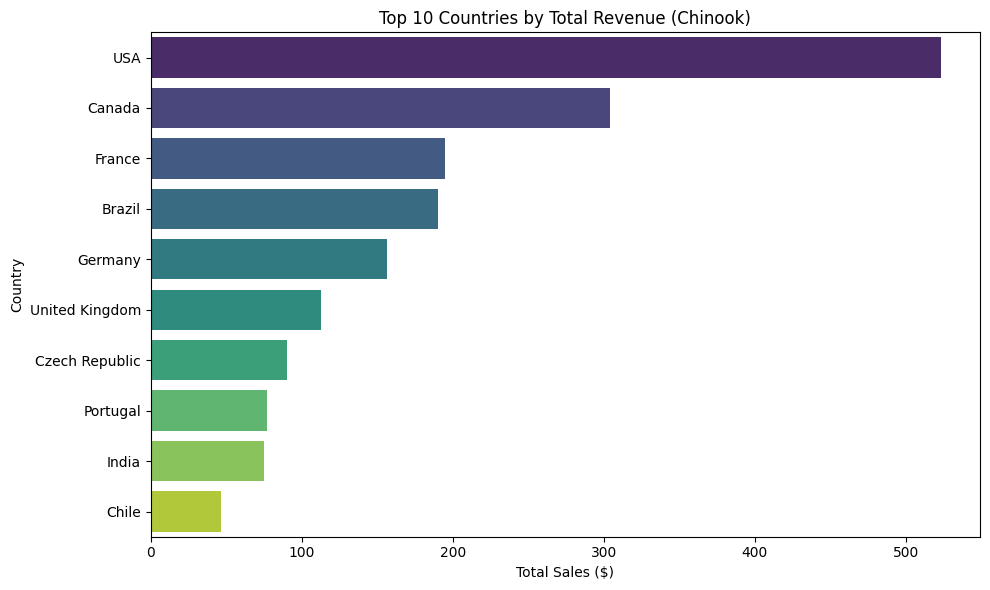

In [128]:
# Query targeting only the top 10 countries

query = """
SELECT BillingCountry, SUM(Total) AS TotalRevenue
FROM invoices
GROUP BY BillingCountry
ORDER BY TotalRevenue DESC
LIMIT 10;
"""
df_top_countries = pd.read_sql_query(query, db_con)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_top_countries,
    x='TotalRevenue',
    y='BillingCountry',
    hue='BillingCountry',
    palette='viridis',
    legend=False)
#sns.barplot(data=df_top_countries, x='TotalRevenue', y='BillingCountry', palette='viridis')
plt.title('Top 10 Countries by Total Revenue (Chinook)')
plt.xlabel('Total Sales ($)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

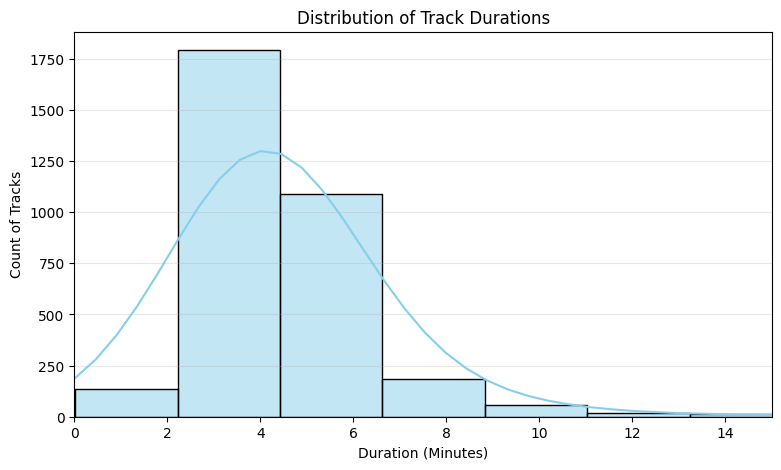

In [129]:
# Query pulling only lengths in minutes to keep data lean
query = """
SELECT (Milliseconds / 60000.0) AS DurationMinutes
FROM tracks
WHERE Milliseconds IS NOT NULL;
"""
df_lengths = pd.read_sql_query(query, db_con)

# Plotting the distribution
plt.figure(figsize=(9, 5))
sns.histplot(data=df_lengths, x='DurationMinutes', bins=40, kde=True, color='skyblue')

plt.xlim(0, 15) # Excludes severe outliers/long audiobooks for better scaling
plt.title('Distribution of Track Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Count of Tracks')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Phase 4. Ask and Answer Your Own Questions


- What artists make the most money?

In [130]:
# Find out which artists drive the most revenue.
# The information is spread across four different tables:
# - invoice_items
# - TracksId
# - AlbumId
# - ArtistsId

query = '''
SELECT art.Name AS ArtistName,
        SUM(ii.UnitPrice * ii.Quantity) AS TotalRevenue,
    COUNT(ii.TrackId) AS TotalTracksSold
FROM invoice_items ii
INNER JOIN tracks t ON ii.TrackId = t.TrackId
INNER JOIN albums al ON t.AlbumId = al.AlbumId
INNER JOIN artists art ON al.ArtistId = art.ArtistId
GROUP BY art.Name
ORDER BY TotalRevenue DESC
LIMIT 10;
'''

df_top_artists = pd.read_sql_query(query, db_con)
df_top_artists

,ArtistName,TotalRevenue,TotalTracksSold
0,Iron Maiden,138.60,140
1,U2,105.93,107
2,Metallica,90.09,91
3,Led Zeppelin,86.13,87
4,Lost,81.59,41
5,The Office,49.75,25
6,Os Paralamas Do Sucesso,44.55,45
7,Deep Purple,43.56,44
8,Faith No More,41.58,42
9,Eric Clapton,39.60,40


- Does the business have repeat customers, or do they only buy once?

In [131]:
# Table of customers and their total orders side-by-side

query = '''
SELECT
    CustomerId,
    COUNT(InvoiceId) AS TotalOrders
FROM invoices
GROUP BY CustomerId
ORDER BY TotalOrders DESC
LIMIT 10;
'''
# Pass the query and your active database connection variable
df_retention = pd.read_sql_query(query, db_con)
df_retention

,CustomerId,TotalOrders
0,1,7
1,2,7
2,3,7
3,4,7
4,5,7
5,6,7
6,7,7
7,8,7
8,9,7
9,10,7


In [132]:
# Analyzing customer purchases

query = '''
SELECT
    sub.CustomerName,
    sub.NumberOfOrders
FROM (
    SELECT
        c.FirstName || ' ' || c.LastName AS CustomerName,
        COUNT(i.InvoiceId) AS NumberOfOrders
    FROM invoices i
    INNER JOIN customers c ON i.CustomerId = c.CustomerId
    GROUP BY c.CustomerId, c.FirstName, c.LastName
) AS sub
ORDER BY sub.NumberOfOrders ASC, sub.CustomerName ASC

LIMIT 10;
'''

print("Executing detailed customer retention query...")

# Running query with active connection
df_individual_retention = pd.read_sql_query(query, db_con)

# Display the final resulting DataFrame
df_individual_retention

Executing detailed customer retention query...


,CustomerName,NumberOfOrders
0,Puja Srivastava,6
1,Aaron Mitchell,7
2,Alexandre Rocha,7
3,Astrid Gruber,7
4,Bjørn Hansen,7
5,Camille Bernard,7
6,Daan Peeters,7
7,Dan Miller,7
8,Diego Gutiérrez,7
9,Dominique Lefebvre,7


## EXTRA CREDIT:
* Use a CTE
* Use a query that joins two or more tables.
* Make a model to see if you can predict something ( e.g. GNB classifier, linear regression )
* Come up with something else cool to do with your data
